# Fake News Detection PT

Dataset: https://github.com/ro-afonso/fake-news-pt-eu

## Pipeline steps:
  1. Load raw CSV
  2. Inspect domain / label distribution
  3. Plot raw label distribution
  4. Preprocess (NaN removal, normalisation, deduplication, outlier filtering)
  5. Create stratified train / validation / test subsets (80 / 10 / 10)
  6. Plot preprocessed data distributions

### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from urllib.parse import urlparse
import re, os, warnings

#### Data loading

In [2]:
def load_raw_data(path: str = "../data/dataset.csv") -> pd.DataFrame:
    """Load the raw dataset CSV and print a quick summary."""
    df = pd.read_csv(path)
    print(df.head(5))
    print("Summary:\n", df.describe())
    return df

In [3]:
df = load_raw_data("../data/dataset.csv")

                                                Text           Source  \
0  PJ em operação internacional de tráfico de dro...               DN   
1  O texto foi criado - numa universidade da Repú...              NaN   
2  Nunca pague multas por conduzir sem carta ou s...  Contas Poupança   
3  Depois de António Guterres, uma estátua de D. ...    redes sociais   
4  O MAR, uma droga gratuita que cura pelo menos ...           Coruja   

                                                 URL  Label  
0  https://www.dn.pt/sociedade/pj-em-operacao-int...      1  
1  https://poligrafo.sapo.pt/fact-check/fact-chec...      1  
2  https://arquivo.pt/wayback/20200626170105mp_/h...      0  
3  https://poligrafo.sapo.pt/fact-check/fact-chec...      0  
4  https://arquivo.pt/wayback/20181012145922mp_/h...      0  
Summary:
               Label
count  63236.000000
mean       0.501550
std        0.500002
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000

#### Inspect domain/label distribution

In [4]:
class DataInspector:
    """
    Inspect domain / label characteristics of a raw news DataFrame.

    Expects columns: URL, Label, Text.
    """

    def __init__(self, df: pd.DataFrame):
        """Initializes the DataInspector class."""
        self.df = df.copy()
        self.df["website"] = self.df["URL"].apply(self._extract_domain)

    # Public methods
    def articles_per_website(self) -> pd.Series:
        """Return and print total article counts per domain."""
        counts = self.df["website"].value_counts()
        print("=== Total articles per website ===")
        print(counts)
        return counts

    def label_counts_per_website(self) -> pd.DataFrame:
        """Return and print a cross-tab of domain × label."""
        cross = pd.crosstab(self.df["website"], self.df["Label"])
        print("=== Label counts per website ===")
        print(cross)
        return cross

    def label_distribution(self) -> pd.Series:
        """Return and print the normalised label distribution."""
        dist = self.df["Label"].value_counts(normalize=True)
        print("=== Label distribution ===")
        print(dist)
        return dist

    def sample_by_label(self, label: int, n: int = 20) -> pd.DataFrame:
        """Return *n* random rows for *label* (0 = fake, 1 = real)."""
        return self.df[self.df["Label"] == label].sample(n)
        
    # Internal helpers
    @staticmethod
    def _extract_domain(url: str) -> str:
        return urlparse(url).netloc.replace("www.", "")

In [5]:
inspector = DataInspector(df)
inspector.articles_per_website()
inspector.label_counts_per_website()
inspector.label_distribution()
df_raw = inspector.df   # has 'website' column

=== Total articles per website ===
website
sicnoticias.pt         14718
arquivo.pt             13561
poligrafo.sapo.pt       6484
direitapolitica.com     6414
dn.pt                   5369
expresso.pt             4533
magazinelusa.com        3652
jn.pt                   2989
observador.pt           2475
sol.sapo.pt              950
tuga.press               924
semanarioextra.com       710
partilhei.com            238
publico.pt               219
Name: count, dtype: int64
=== Label counts per website ===
Label                    0      1
website                          
arquivo.pt           13561      0
direitapolitica.com   6414      0
dn.pt                    0   5369
expresso.pt              0   4533
jn.pt                    0   2989
magazinelusa.com      3652      0
observador.pt         2385     90
partilhei.com          238      0
poligrafo.sapo.pt     3559   2925
publico.pt              77    142
semanarioextra.com     710      0
sicnoticias.pt           0  14718
sol.sapo.pt     

### Data Analysis (before proceeding with data pre-processing)

The <strong>BasePlotter</strong> can be reused to show the pre-processed just by recalling the function afterwards at the end of the data pre-processing step.

In [6]:
class BasePlotter:
    """
    Shared plotting logic for both raw and clean DataFrames.
 
    Subclasses set TAG and call super().__init__(df). All plot methods are
    inherited and titled automatically with the subclass tag.
    Length columns (text_length_chars, text_length_words) are computed on the
    fly if absent from the DataFrame.
    """
 
    TAG: str = ""
 
    # Palette shared by all plots — red = fake, blue = real
    PALETTE:     dict = {0: "#E57373", 1: "#64B5F6"}
    LABEL_NAMES: dict = {0: "Fake",    1: "Real"}
 
    def __init__(self, df: pd.DataFrame):
        self.df = self._ensure_length_cols(df.copy())
 
    # ------------------------------------------------------------------
    # Label distribution
    # ------------------------------------------------------------------
 
    def plot_label_distribution(self, save_path: str = None) -> None:
        """Counted bar chart of label distribution."""
        fig, ax = plt.subplots(figsize=(7, 4))
        fig.suptitle(self._title("Label Distribution"), fontsize=13, fontweight="bold")
    
        counts = self.df["Label"].value_counts().sort_index()
    
        bars = ax.bar(
            [self.LABEL_NAMES[k] for k in counts.index],
            counts.values,
            color=[self.PALETTE[k] for k in counts.index],
            edgecolor="white", linewidth=0.8,
        )
    
        for bar, val in zip(bars, counts.values):
            ax.text(
                bar.get_x() + bar.get_width() / 2, bar.get_height() + counts.max() * 0.01, f"{val:,}",
                ha="center",
                va="bottom",
                fontsize=10,
            )
    
        ax.set_title("Count")
        ax.set_ylabel("Number of articles")
        ax.set_xlabel("Label")
    
        plt.tight_layout()
        self._save_and_show(fig, save_path)
 
    # ------------------------------------------------------------------
    # Text-length distributions
    # ------------------------------------------------------------------
 
    def plot_word_length_histogram(self, save_path: str = None) -> None:
        """KDE + overlapping histogram of word counts split by label."""
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(self._title("Word-Count Distribution by Label"),
                     fontsize=13, fontweight="bold")
 
        for label, group in self.df.groupby("Label"):
            sns.kdeplot(
                group["text_length_words"], ax=axes[0],
                label=self.LABEL_NAMES[label], color=self.PALETTE[label],
                fill=True, alpha=0.35, linewidth=1.8,
            )
        axes[0].set_title("KDE per label")
        axes[0].set_xlabel("Words")
        axes[0].legend()
        axes[0].grid(axis="y", alpha=0.4)
 
        for label, group in self.df.groupby("Label"):
            axes[1].hist(
                group["text_length_words"], bins=50, alpha=0.6,
                label=self.LABEL_NAMES[label], color=self.PALETTE[label],
                edgecolor="none",
            )
        axes[1].set_title("Histogram (overlapping)")
        axes[1].set_xlabel("Words")
        axes[1].set_ylabel("Count")
        axes[1].legend()
        axes[1].grid(axis="y", alpha=0.4)
 
        plt.tight_layout()
        self._save_and_show(fig, save_path)
 
    def plot_char_length_histogram(self, save_path: str = None) -> None:
        """KDE of character counts split by label."""
        fig, ax = plt.subplots(figsize=(10, 5))
        for label, group in self.df.groupby("Label"):
            sns.kdeplot(
                group["text_length_chars"], ax=ax,
                label=self.LABEL_NAMES[label], color=self.PALETTE[label],
                fill=True, alpha=0.35, linewidth=1.8,
            )
        ax.set_title(self._title("Character-Count Distribution by Label"))
        ax.set_xlabel("Characters")
        ax.legend()
        ax.grid(axis="y", alpha=0.4)
        plt.tight_layout()
        self._save_and_show(fig, save_path)
 
    def plot_length_boxplots(self, save_path: str = None) -> None:
        """Side-by-side boxplots of word and character counts grouped by label."""
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        fig.suptitle(self._title("Text-Length Boxplots by Label"),
                     fontsize=13, fontweight="bold")
 
        df_plot = self.df.copy()
        df_plot["Label"] = df_plot["Label"].map(self.LABEL_NAMES)
        palette = {"Fake": self.PALETTE[0], "Real": self.PALETTE[1]}
 
        for ax, col, ylabel in [
            (axes[0], "text_length_words", "Words"),
            (axes[1], "text_length_chars", "Characters"),
        ]:
            sns.boxplot(data=df_plot, x="Label", y=col, palette=palette,
                        ax=ax, width=0.45)
            ax.set_title(ylabel)
            ax.set_ylabel(ylabel)
 
        plt.tight_layout()
        self._save_and_show(fig, save_path)
 
    # ------------------------------------------------------------------
    # Descriptive statistics
    # ------------------------------------------------------------------
 
    def plot_descriptive_stats(self, save_path: str = None) -> None:
        """Grouped bar chart: mean / median / std of word counts per label."""
        stats = (
            self.df.groupby("Label")["text_length_words"]
            .agg(["mean", "median", "std"])
            .rename(index=self.LABEL_NAMES)
        )
 
        fig, ax = plt.subplots(figsize=(9, 5))
        x      = range(len(stats.columns))
        width  = 0.35
        colors = [self.PALETTE[0], self.PALETTE[1]]
 
        for i, (idx, row) in enumerate(stats.iterrows()):
            offset = (i - 0.5) * width
            bars = ax.bar(
                [xi + offset for xi in x], row.values,
                width=width, label=idx, color=colors[i], edgecolor="white",
            )
            for bar, val in zip(bars, row.values):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 1, f"{val:.0f}",
                        ha="center", va="bottom", fontsize=9)
 
        ax.set_xticks(list(x))
        ax.set_xticklabels(["Mean", "Median", "Std Dev"])
        ax.set_ylabel("Words")
        ax.set_title(self._title("Word-Count Statistics per Label"))
        ax.legend()
        ax.grid(axis="y", alpha=0.4)
        plt.tight_layout()
        self._save_and_show(fig, save_path)
 
    # ------------------------------------------------------------------
    # Domain / source analysis
    # ------------------------------------------------------------------
 
    def plot_top_domains(self, top_n: int = 15, save_path: str = None) -> None:
        """Stacked horizontal bar chart of article counts per domain."""
        if "website" not in self.df.columns:
            print("'website' column not found — run DataInspector first.")
            return
 
        cross = (
            pd.crosstab(self.df["website"], self.df["Label"])
            .rename(columns=self.LABEL_NAMES)
        )
        cross["total"] = cross.sum(axis=1)
        cross = cross.nlargest(top_n, "total").drop(columns="total")
 
        fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.45)))
        cross.plot(kind="barh", stacked=True, ax=ax,
                   color=[self.PALETTE[0], self.PALETTE[1]], edgecolor="white")
        ax.set_title(self._title(f"Top {top_n} Domains by Article Count"))
        ax.set_xlabel("Articles")
        ax.legend(title="Label")
        ax.invert_yaxis()
        plt.tight_layout()
        self._save_and_show(fig, save_path)
 
    def plot_domain_label_heatmap(self, top_n: int = 15, save_path: str = None) -> None:
        """Heatmap of normalised label proportions per domain."""
        if "website" not in self.df.columns:
            print("'website' column not found — run DataInspector first.")
            return
 
        cross = pd.crosstab(self.df["website"], self.df["Label"], normalize="index")
        cross.columns = [self.LABEL_NAMES[c] for c in cross.columns]
        cross["total"] = self.df["website"].value_counts()
        cross = cross.nlargest(top_n, "total").drop(columns="total")
 
        fig, ax = plt.subplots(figsize=(7, max(5, top_n * 0.45)))
        sns.heatmap(cross, annot=True, fmt=".2f", cmap="RdBu_r",
                    linewidths=0.5, linecolor="white", vmin=0, vmax=1, ax=ax)
        ax.set_title(self._title(f"Label Proportion per Domain (top {top_n})"))
        ax.set_ylabel("Domain")
        plt.tight_layout()
        self._save_and_show(fig, save_path)
 
    # ------------------------------------------------------------------
    # Missing-value / data-quality overview
    # ------------------------------------------------------------------
 
    def plot_missing_values(self, save_path: str = None) -> None:
        """Bar chart of missing-value counts per column."""
        missing = self.df.isnull().sum()
        missing = missing[missing > 0]
 
        if missing.empty:
            print(f"[{self.TAG}] No missing values found.")
            return
 
        fig, ax = plt.subplots(figsize=(8, 4))
        missing.sort_values(ascending=False).plot(kind="bar", ax=ax, color="#FFB74D")
        ax.set_title(self._title("Missing Values per Column"))
        ax.set_ylabel("Count")
        ax.set_xlabel("Column")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        self._save_and_show(fig, save_path)
 
    def plot_duplicate_summary(self, save_path: str = None) -> None:
        """Bar chart comparing unique vs duplicate article counts."""
        total      = len(self.df)
        duplicates = self.df.duplicated(subset=["Text"]).sum()
        unique     = total - duplicates
 
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.bar(["Unique", "Duplicates"], [unique, duplicates],
               color=["#81C784", "#E57373"], edgecolor="white")
        for x, val in enumerate([unique, duplicates]):
            ax.text(x, val + total * 0.005, f"{val:,}", ha="center", fontsize=10)
        ax.set_title(self._title("Unique vs Duplicate Articles"))
        ax.set_ylabel("Count")
        plt.tight_layout()
        self._save_and_show(fig, save_path)
 
    # ------------------------------------------------------------------
    # Convenience
    # ------------------------------------------------------------------
 
    def plot_all(self, save_dir: str = None) -> None:
        """Render every available plot. Saves figures to *save_dir* if provided."""
        def sp(name):
            return f"{save_dir}/{self.TAG}_{name}.png" if save_dir else None
 
        self.plot_label_distribution(sp("label_distribution"))
        self.plot_word_length_histogram(sp("word_length_histogram"))
        self.plot_char_length_histogram(sp("char_length_histogram"))
        self.plot_length_boxplots(sp("length_boxplots"))
        self.plot_descriptive_stats(sp("descriptive_stats"))
        self.plot_missing_values(sp("missing_values"))
        self.plot_duplicate_summary(sp("duplicate_summary"))
        if "website" in self.df.columns:
            self.plot_top_domains(save_path=sp("top_domains"))
            self.plot_domain_label_heatmap(save_path=sp("domain_label_heatmap"))
 
    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------
 
    def _title(self, base: str) -> str:
        return f"[{self.TAG}] {base}" if self.TAG else base
 
    @staticmethod
    def _ensure_length_cols(df: pd.DataFrame) -> pd.DataFrame:
        if "text_length_chars" not in df.columns:
            df["text_length_chars"] = df["Text"].str.len()
        if "text_length_words" not in df.columns:
            df["text_length_words"] = df["Text"].str.split().apply(len)
        return df
 
    @staticmethod
    def _save_and_show(fig: plt.Figure, save_path: str = None) -> None:
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()
        plt.close(fig)

In [7]:
class RawDataPlotter(BasePlotter):
    """
    Plots for the raw, unprocessed DataFrame.
 
    Extends BasePlotter with raw-specific plots:
      - Missing-value breakdown per column
      - Duplicate article count
      - Domain distribution (requires 'website' column from DataInspector)
    All inherited plots are titled with the [Raw] tag.
    """
 
    TAG = "Raw"
 
    def __init__(self, df: pd.DataFrame):
        super().__init__(df)
 
    def plot_all(self, save_dir: str = None) -> None:
        """Render all raw-stage plots in logical order."""
        def sp(name):
            return f"{save_dir}/{self.TAG}_{name}.png" if save_dir else None
 
        # Overview
        self.plot_label_distribution(sp("label_distribution"))
        self.plot_missing_values(sp("missing_values"))
        self.plot_duplicate_summary(sp("duplicate_summary"))
        
        # Text-length distributions
        self.plot_word_length_histogram(sp("word_length_histogram"))
        self.plot_char_length_histogram(sp("char_length_histogram"))
        self.plot_length_boxplots(sp("length_boxplots"))
        self.plot_descriptive_stats(sp("descriptive_stats"))
        
        # Domain analysis
        if "website" in self.df.columns:
            self.plot_top_domains(save_path=sp("top_domains"))
            self.plot_domain_label_heatmap(save_path=sp("domain_label_heatmap"))

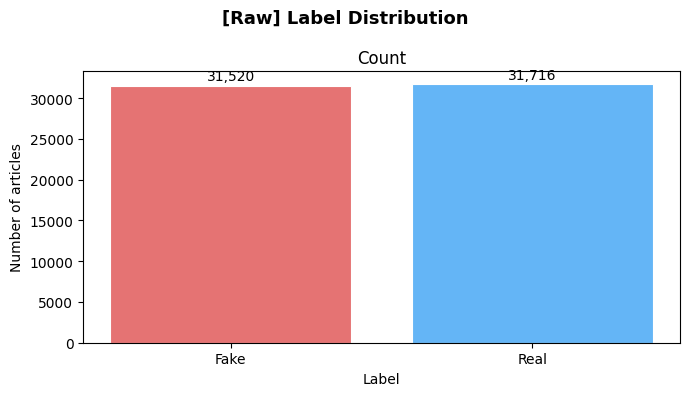

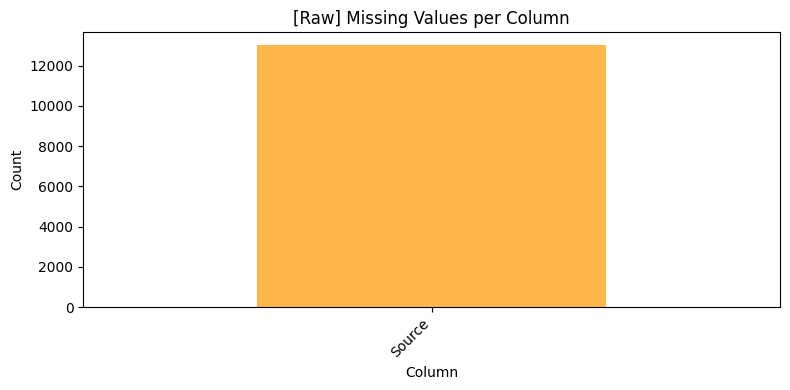

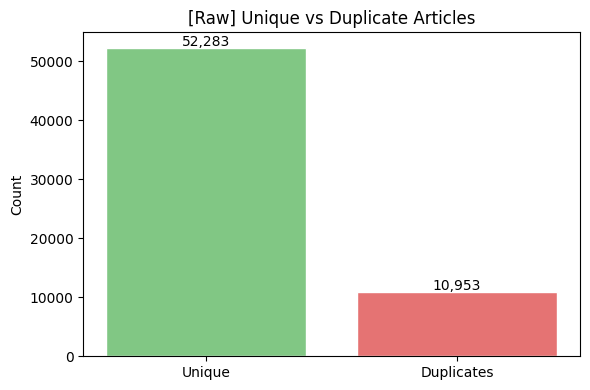

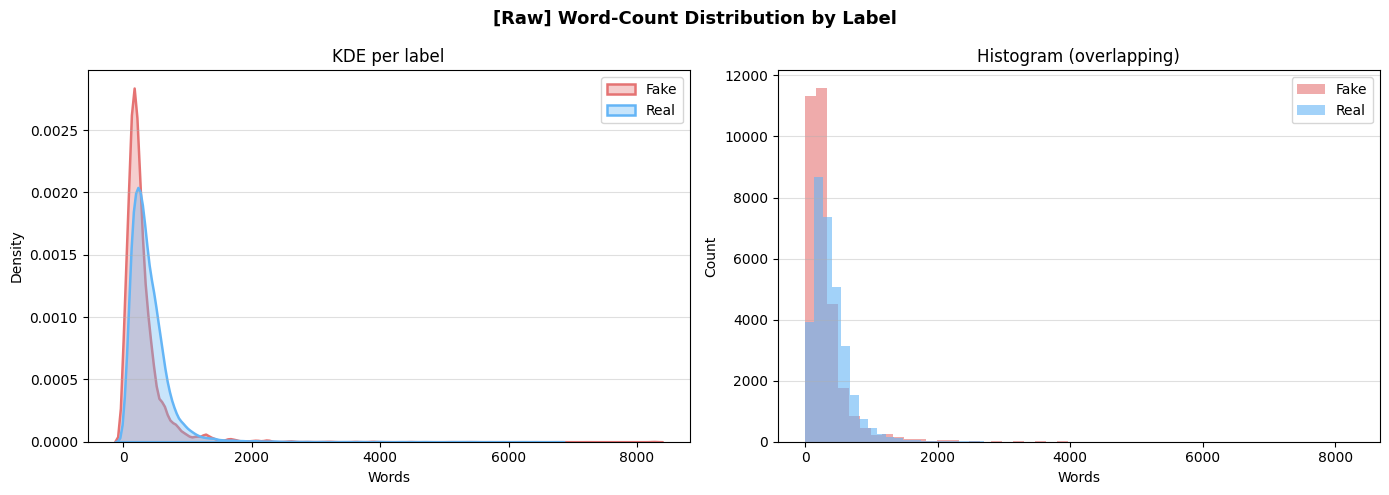

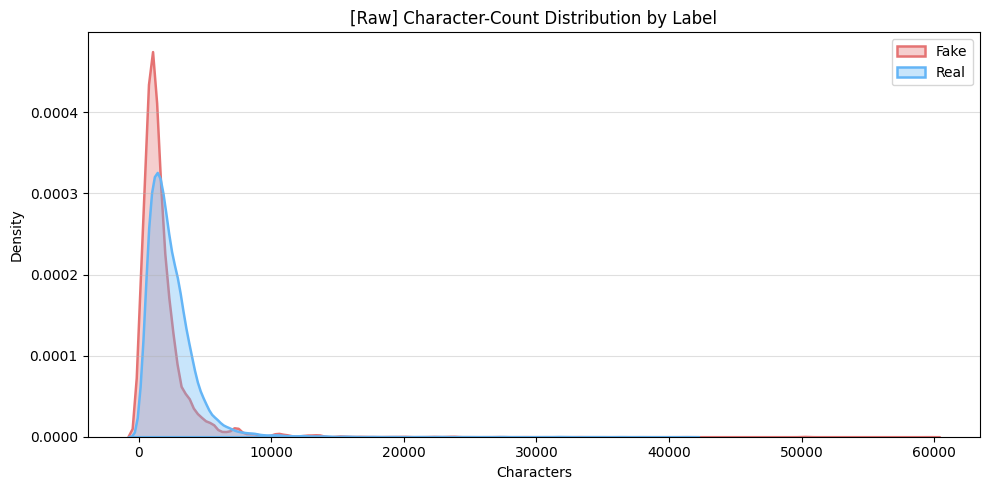

/tmp/ipykernel_57500/792802155.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="Label", y=col, palette=palette,
/tmp/ipykernel_57500/792802155.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="Label", y=col, palette=palette,


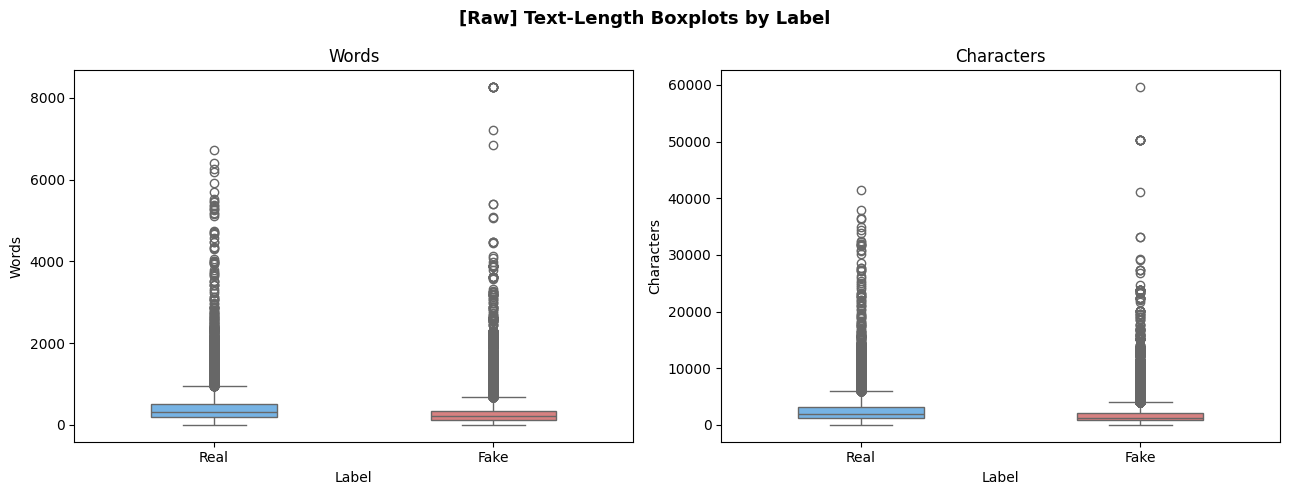

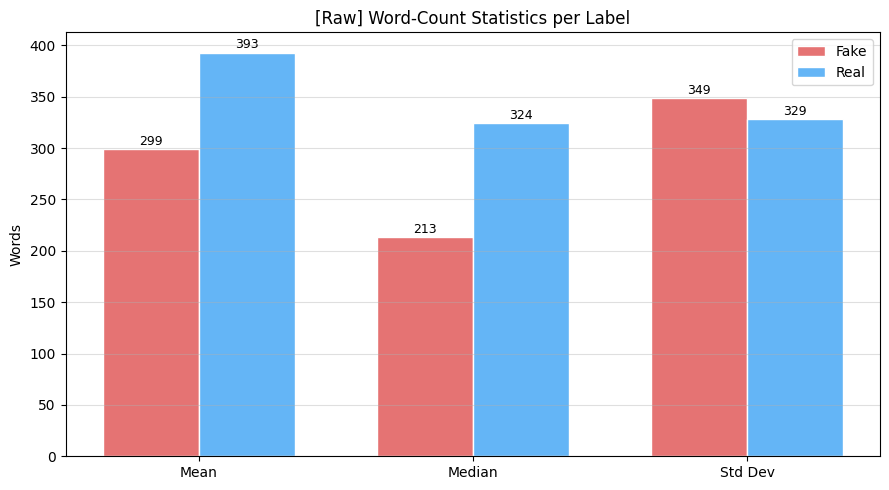

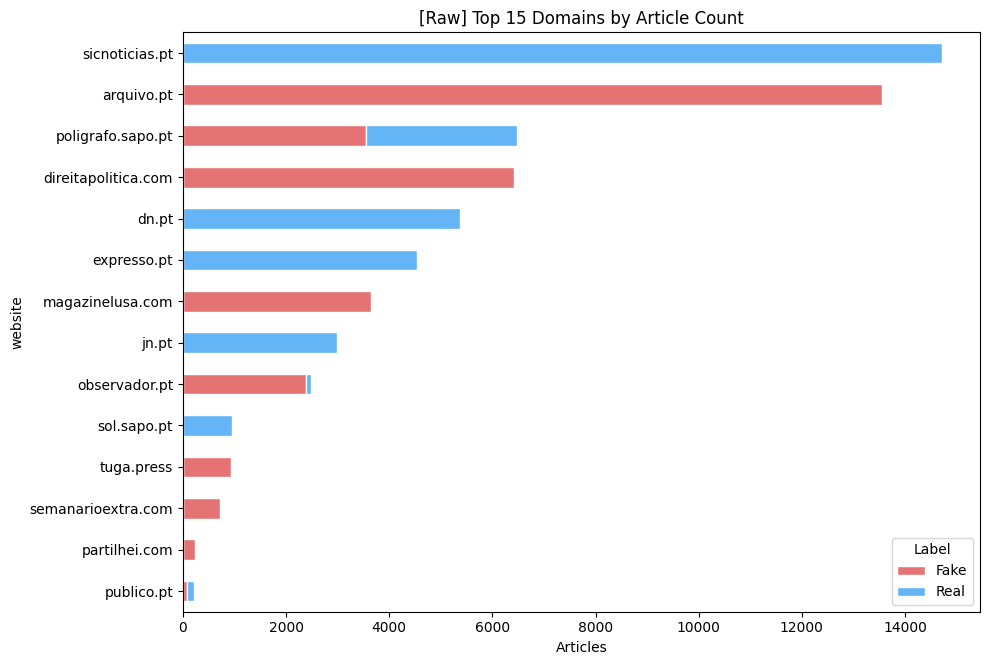

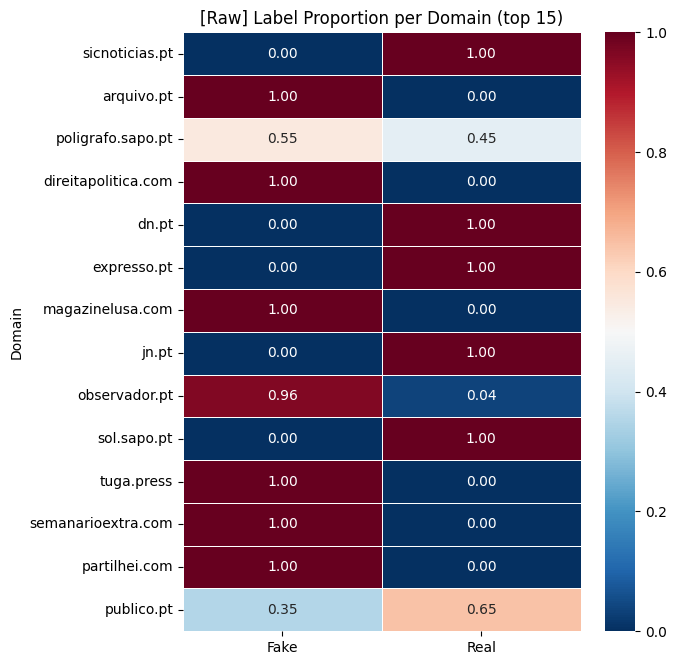

In [8]:
raw_plotter = RawDataPlotter(df_raw)
raw_plotter.plot_all(save_dir="../plots")

### Data Pre-Processing

Clean a raw news DataFrame through a standard sequence of steps:
  1. Drop rows with missing Text
  2. Normalise whitespace
  3. Drop duplicate articles
  4. Add character / word length columns
  5. Filter extreme length outliers
  6. Save to disk

In [9]:
class DataPreprocessor:
    """
    This class defines the Data Pre-processing pipeline steps.
    """

    def __init__(
        self,
        df:              pd.DataFrame,
        min_word_length: int = 2,
        max_word_length: int = 512,
        output_path:     str = "../data/dataset_preprocessed.csv",
    ):
        self.df              = df.copy()
        self.min_word_length = min_word_length
        self.max_word_length = max_word_length
        self.output_path     = output_path

    def run(self) -> pd.DataFrame:
        """Execute the full preprocessing pipeline and return the clean DataFrame."""
        self._drop_missing()
        self._normalize()
        self._deduplicate()
        self._add_length_columns()
        self._filter_outliers()
        self._save()
        return self.df
        
    # Pipeline
    def _drop_missing(self) -> None:
        before = len(self.df)
        self.df = self.df.dropna(subset=["Text"]).reset_index(drop=True)
        dropped = before - len(self.df)
        print(f"Total samples after NaN removal: {len(self.df):,} (dropped {dropped} rows)")

    def _normalize(self) -> None:
        self.df["Text"] = self.df["Text"].apply(self.normalize_text)

    def _deduplicate(self) -> None:
        self.df = self.df.drop_duplicates(subset=["Text"])

    def _add_length_columns(self) -> None:
        self.df["text_length_chars"] = self.df["Text"].str.len()
        self.df["text_length_words"] = self.df["Text"].str.split().apply(len)

    def _filter_outliers(self) -> None:
        self.df = self.df[self.df["text_length_words"] > self.min_word_length]
        self.df = self.df[self.df["text_length_words"] < self.max_word_length]

    def _save(self) -> None:
        self.df.to_csv(self.output_path, index=False)
        print(f"Saved cleaned dataset -> {self.output_path}")

    @staticmethod
    def normalize_text(text: str):
        """
        Light text normalisation:
          - Strip leading / trailing whitespace
          - Collapse internal whitespace runs to a single space
          - Replace newlines with spaces
        """
        text = text.strip()
        text = re.sub(r"\s+", " ", text)
        text = text.replace("\n", " ")
        return text

In [10]:
preprocessor = DataPreprocessor(df)
df_clean = preprocessor.run()

Total samples after NaN removal: 63,236 (dropped 0 rows)
Saved cleaned dataset -> ../data/dataset_preprocessed.csv


In [11]:
df_clean["website"] = df_clean["URL"].apply(
    lambda x: urlparse(x).netloc.replace("www.", "")
)

In [12]:
class CleanDataPlotter(BasePlotter):
    """
    Plots for the preprocessed, cleaned DataFrame.
 
    Extends BasePlotter with a split distribution plot showing how articles
    are distributed across train / val / test after splitting.
    All inherited plots are titled with the [Clean] tag.
    """
 
    TAG = "Clean"
 
    def __init__(self, df):
        super().__init__(df)
 
    def plot_split_distribution(
        self,
        train,
        val,
        test,
        save_path= None,
    ):
        """
        Grouped bar chart showing label counts in each split (train/val/test).
        Call after DataSplitter.get_splits() to confirm stratification held.
        """
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle(self._title("Label Distribution per Split"),
                     fontsize=13, fontweight="bold")
 
        for ax, split_df, title in [
            (axes[0], train, "Train"),
            (axes[1], val,   "Validation"),
            (axes[2], test,  "Test"),
        ]:
            counts = split_df["Label"].value_counts().sort_index()
            bars = ax.bar(
                [self.LABEL_NAMES[k] for k in counts.index],
                counts.values,
                color=[self.PALETTE[k] for k in counts.index],
                edgecolor="white",
            )
            for bar, val_count in zip(bars, counts.values):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + counts.max() * 0.01,
                        f"{val_count:,}", ha="center", va="bottom", fontsize=9)
            ax.set_title(f"{title}  (n={len(split_df):,})")
            ax.set_ylabel("Count")
            ax.set_xlabel("Label")
            ax.grid(axis="y", alpha=0.4)
 
        plt.tight_layout()
        self._save_and_show(fig, save_path)
 
    def plot_all(self, save_dir= None):
        """Render all clean-stage plots in logical order."""
        def sp(name):
            return f"{save_dir}/{self.TAG}_{name}.png" if save_dir else None
 
        # Overview
        self.plot_label_distribution(sp("label_distribution"))
        # Text-length distributions
        self.plot_word_length_histogram(sp("word_length_histogram"))
        self.plot_char_length_histogram(sp("char_length_histogram"))
        self.plot_length_boxplots(sp("length_boxplots"))
        self.plot_descriptive_stats(sp("descriptive_stats"))
        # Domain analysis
        if "website" in self.df.columns:
            self.plot_top_domains(save_path=sp("top_domains"))
            self.plot_domain_label_heatmap(save_path=sp("domain_label_heatmap"))

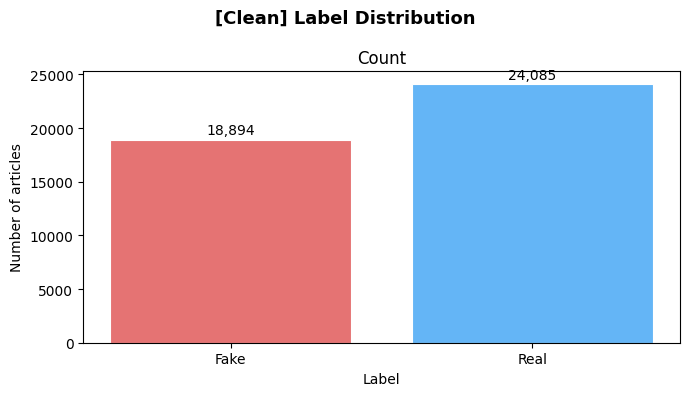

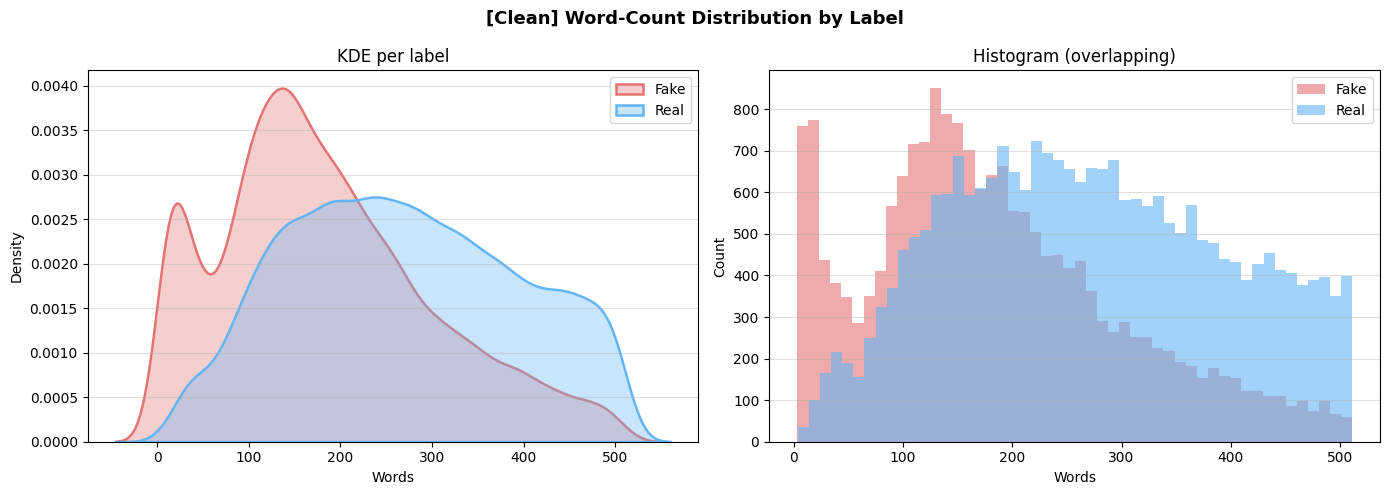

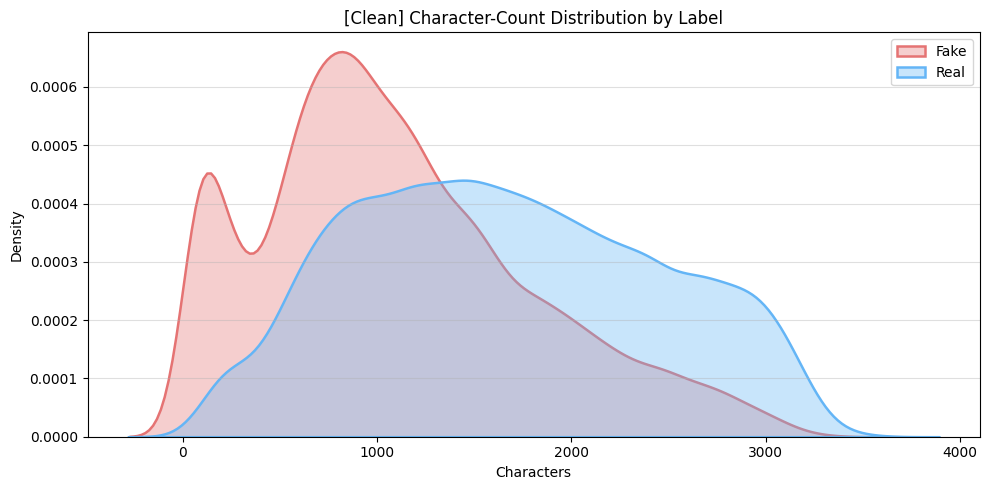

/tmp/ipykernel_57500/792802155.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="Label", y=col, palette=palette,
/tmp/ipykernel_57500/792802155.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="Label", y=col, palette=palette,


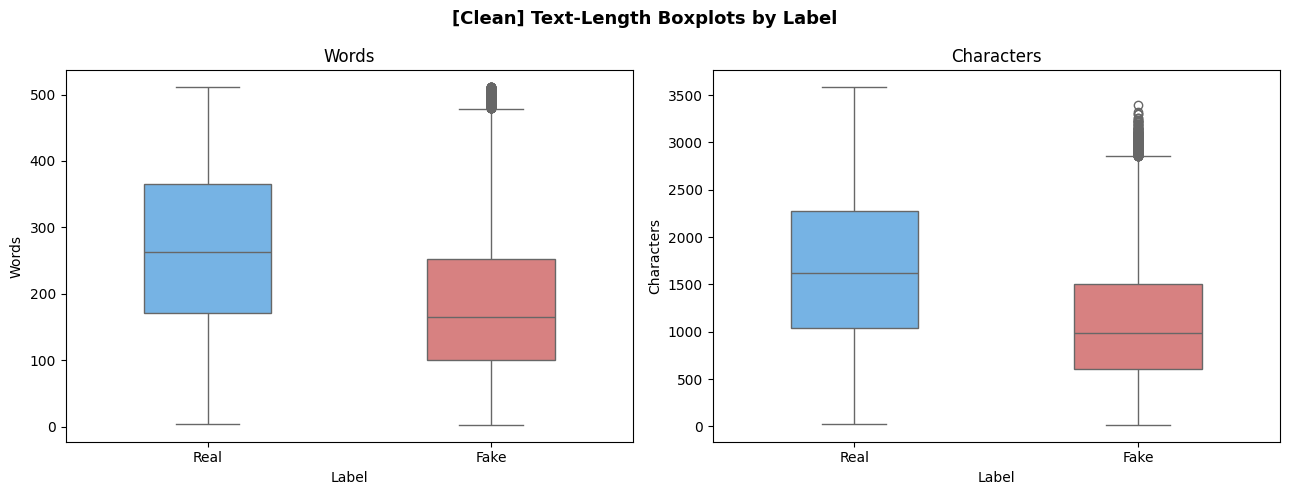

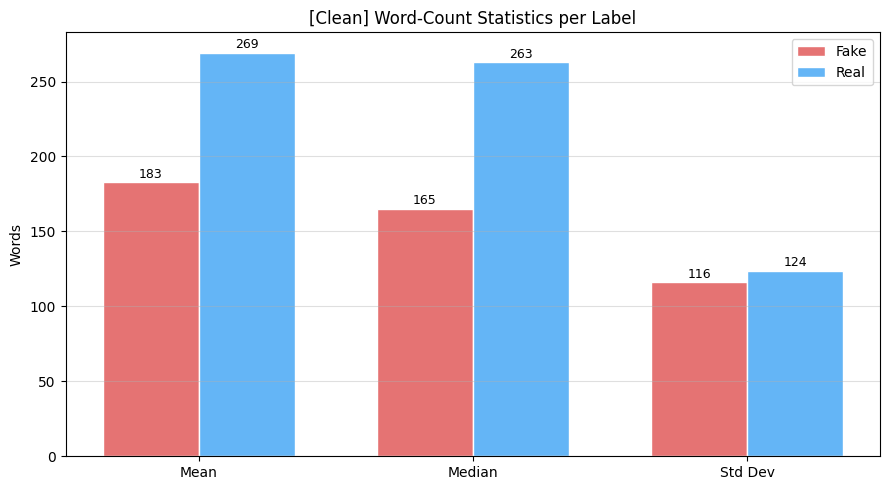

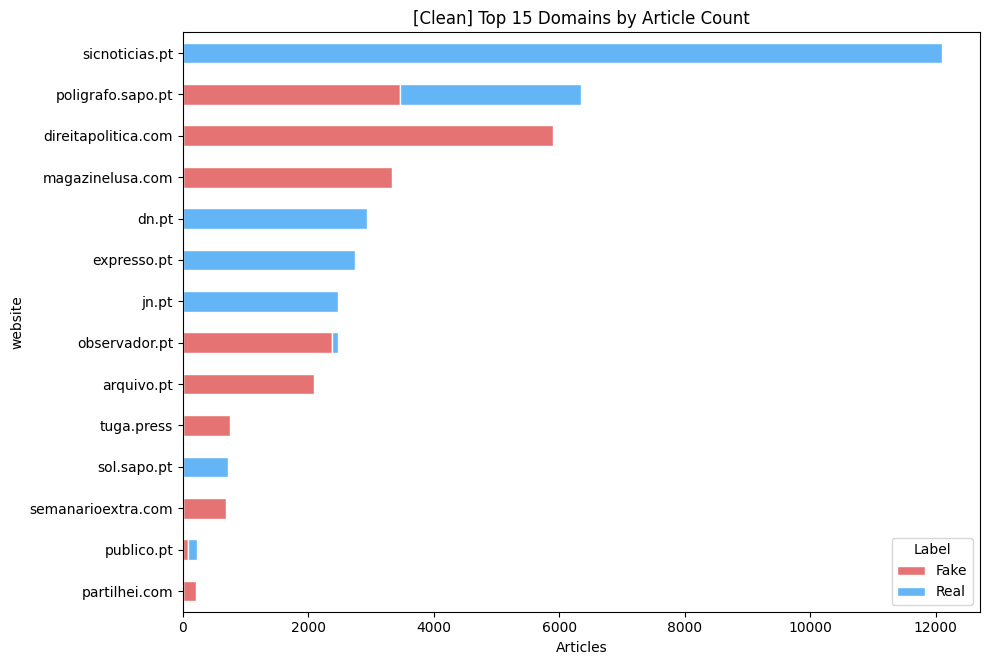

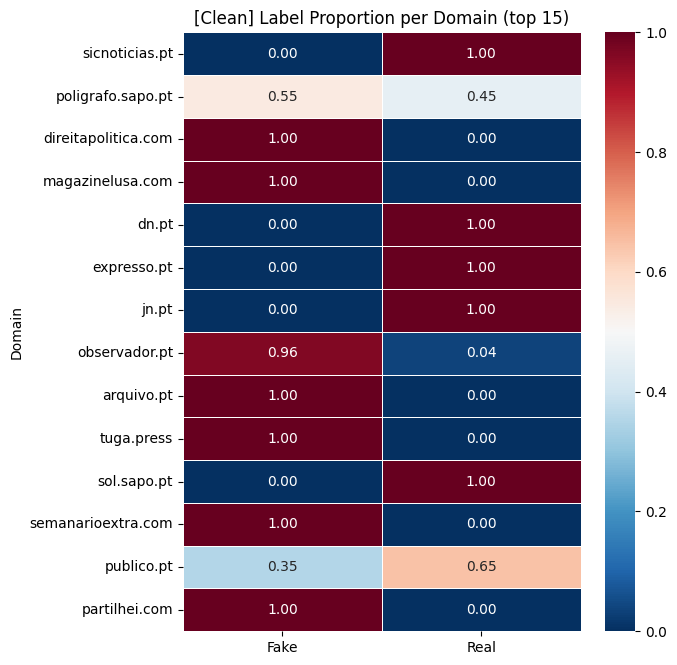

In [13]:
clean_plotter = CleanDataPlotter(df_clean)
clean_plotter.plot_all(save_dir="../plots")

### Data Splitter

Training (80%)/ Validation (10%)/ Testing (10%)

In [14]:
class DataSplitter:
    """
    Split a cleaned DataFrame into stratified train / validation / test sets.
 
    Split ratios: 80 % train, 10 % validation, 10 % test.
    Splits are cached to disk; if all three files already exist they are loaded
    directly without re-splitting.
    """
 
    def __init__(
        self,
        train_path= "../data/train.csv",
        val_path= "../data/validation.csv",
        test_path= "../data/test.csv",
        random_state= 42,
    ):
        self.train_path   = train_path
        self.val_path     = val_path
        self.test_path    = test_path
        self.random_state = random_state
 
    def get_splits(self, df=None):
        """
        Return (train, val, test) DataFrames.
 
        If all three split files already exist on disk they are loaded directly.
        Otherwise *df* (the full cleaned DataFrame) is split and saved.
        """
        if self._splits_exist():
            return self._load_splits()
        if df is None:
            raise ValueError(
                "Split files not found on disk and no DataFrame was provided. "
                "Pass the cleaned DataFrame as the `df` argument."
            )
        return self._create_splits(df)
 
    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------
 
    def _splits_exist(self):
        return all(
            os.path.exists(p)
            for p in [self.train_path, self.val_path, self.test_path]
        )
 
    def _load_splits(self):
        print("Split files already exist, loading from disk...")
        train = pd.read_csv(self.train_path)
        val   = pd.read_csv(self.val_path)
        test  = pd.read_csv(self.test_path)
        return train, val, test
 
    def _create_splits(
        self, df
    ):
        print("Creating train / val / test splits from full cleaned dataset...")
 
        stratify_col = df["Label"] if "Label" in df.columns else None
 
        # 80 / 20 split
        train, temp = train_test_split(
            df,
            test_size=0.2,
            random_state=self.random_state,
            stratify=stratify_col,
        )
 
        # 10 / 10 split from the 20 % temp
        val, test = train_test_split(
            temp,
            test_size=0.5,
            random_state=self.random_state,
            stratify=temp["Label"] if stratify_col is not None else None,
        )
 
        train.to_csv(self.train_path, index=False)
        val.to_csv(self.val_path,     index=False)
        test.to_csv(self.test_path,   index=False)
 
        print(f"Saved -> {self.train_path}, {self.val_path}, {self.test_path}")
        return train, val, test
 
    @staticmethod
    def print_split_summary(
        train,
        val,
        test,
    ):
        print("Train shape:      ", train.shape)
        print("Validation shape: ", val.shape)
        print("Test shape:       ", test.shape)
        print("Label distribution in train:\n", train["Label"].value_counts())

In [15]:
splitter = DataSplitter()
train, val, test = splitter.get_splits(df=df_clean)
DataSplitter.print_split_summary(train, val, test)

Split files already exist, loading from disk...
Train shape:       (34383, 7)
Validation shape:  (4298, 7)
Test shape:        (4298, 7)
Label distribution in train:
 Label
1    19268
0    15115
Name: count, dtype: int64


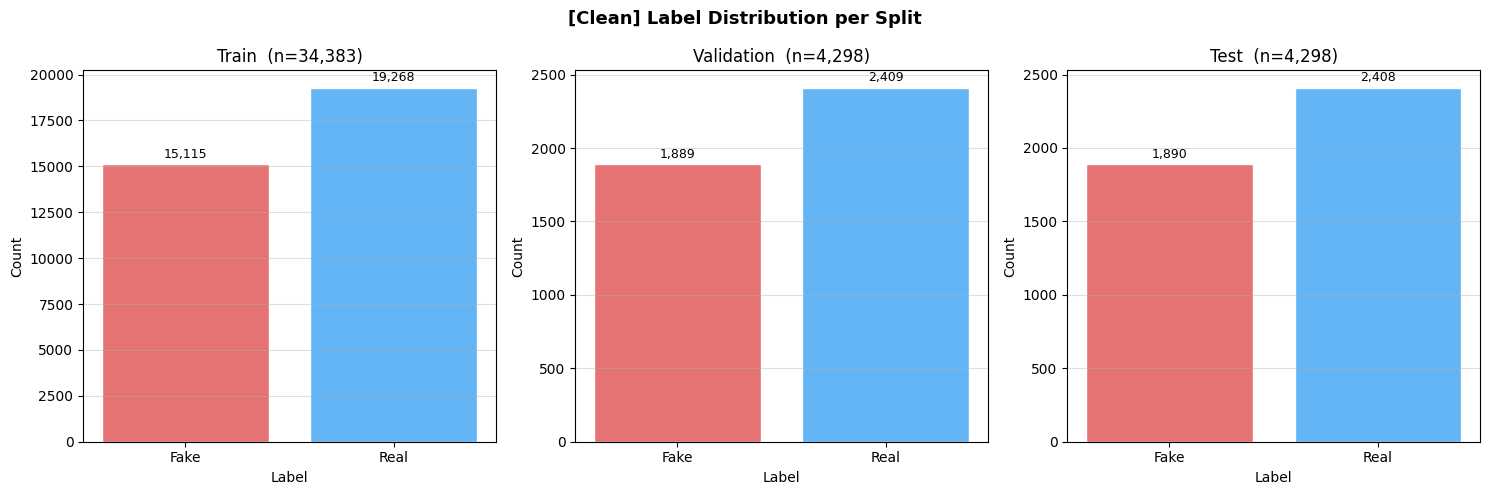

In [16]:
clean_plotter.plot_split_distribution(
    train, val, test,
    save_path="../plots/Clean_split_distribution.png",
)